# CTA 'L' Ridership Analysis
**Dataset:** Daily boardings per station, 2001–present  
**Questions:**
1. Can we predict monthly ridership with a linear regression model?
2. Is there a meaningful difference in ridership between Saturdays and Sundays?
3. Can we visualize ridership at each station over time on the CTA map?

What this notebook does:

1a. Feature engineering (original dataset):
   day_of_week: contains the day of the week (like "Monday"). year:  into year, month, and week. ok

Engineers features for 

**Note:** Claude code wrote all the code for this project! It took like 60k tokens. I probably spent 30 minutes writing my prompt, and claude took probably 30 minutes to generate everything.

Project part 1 text (from canvas).
https://data.cityofchicago.org/Transportation/CTA-Ridership-L-Station-Entries-Daily-Totals/5neh-572f/about_data

Dataset Description:

- This dataset, collected by the (Chicago Transit Authority) CTA shows daily totals for all CTA "L" lines going back to 2001. The "L" (short for elevated) is the rapid transit system for the City of Chicago, and is the fourth largest in the country, with 8 lines and 146 stations.

- There are 5 columns and 1311360 rows (including the head).

- Descriptions of features: 

    stationid: A station ID (int) for internal use only. Nobody who rides the L is familiar with these. A station ID might be something like 40350.
    stationname: The name of the station, i.e. Granville, UIC-Halsted
    date: The date the data was collected on in MM/DD/YYYY format
    daytype: A single char indicating the day type. "W" is a weekday (M-F, not counting holidays), "A" is for Saturdays (not counting holidays), and "U" is for Sundays/holidays. Holidays are New Year's Day, Memorial Day, Independence Day, Labor Day, Thanksgiving, and Christmas Day.
    Ridership: Total ridership for the day, an integer

Motivation and interest:

    I grew up in Chicago, so when I saw a CTA dataset on data.gov, I went to the source and found this wonderful dataset containing station entry data for every CTA station on every day since 2001. I'm also a massive transit nerd, so this dataset spoke to me. I've also got a personal connection (I've taken the L a lot of times).
    It's probably useful for policymakers trying to make decisions about adjusting L service to demand. For example, if you compared ridership per day to train frequency on those days, you could learn that you're overserving or underserving certain lines. 

Questions and Hypothesis:

    Can we predict how many riders there will be in a given month?
    Is there a meaningful difference between ridership on Saturdays vs Sundays?
    Can we visualize ridership at each station over time using the CTA's map dataset? Links to an external site.

Planned Approach

    I want to make separate datasets for daytypes, weeks, and months. The last goal will be very clunky if we try and use every day as a datapoint (there's 1.3 million rows). 
    I want to engineer total ridership per day across the entire L network. 
    I want to do a linear regression on the full dataset to accomplish Q1. I'll choose some days and see if the model can predict them. I'm very interested if a linear regression model can predict the ridership for a very strange month, like the first few months of COVID. The dataset also only goes to February 2026, but there is ridership data out there for March and April. I want to see if my model can accurately predict the real values. 
    For Q2 I'm actually going to use a paired t-test.
    For Q3 I'm going to use the aforementioned map dataset to plot each stop on the map. Then I'm going to use plotly so I can animate the ridership of all the stops for each week/month with a heatmap. The goal is to be able to watch how ridership has changed over the years with a slick animation.

AI Tool Selection

    I'm going to use Claude and Claude code.
    I'm very confident using Claude, but less so with Claude Code. I've only used it for a few small things, so this will be the first time using it on a larger project
    Other tools: git + github for version control, vscode. 



## 0 — Imports & paths

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import contextily as ctx
from pyproj import Transformer
import holidays
from pathlib import Path
import warnings
import folium
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)

DATA_DIR = Path('.')
RIDERSHIP_RAW  = DATA_DIR / 'CTA-Ridership.csv'.
LSTOPS_RAW     = DATA_DIR / 'CTA-Lstops.csv'
DF1_CACHE      = DATA_DIR / 'engineered_daily.csv'
DF2_CACHE      = DATA_DIR / 'engineered_station_agg.csv'
DF3_CACHE      = DATA_DIR / 'engineered_network_daily.csv'

## 1 — Load raw data

In [42]:
raw = pd.read_csv(
    RIDERSHIP_RAW,
    dtype={'station_id': 'int32', 'daytype': 'category'},
    thousands=',',      # rides column has commas like '1,059'
)
# Normalise the rides column name — file header says 'rides' not 'ridership'
raw.rename(columns={'rides': 'ridership'}, inplace=True)
raw['ridership'] = raw['ridership'].astype('int32')
raw['date'] = pd.to_datetime(raw['date'], format='%m/%d/%Y')

print(f"Rows: {len(raw):,}  |  Columns: {list(raw.columns)}")
raw.head()

Rows: 1,311,359  |  Columns: ['station_id', 'stationname', 'date', 'daytype', 'ridership']


,station_id,stationname,date,daytype,ridership
0,40350,UIC-Halsted,2001-01-01,U,273
1,41130,Halsted-Orange,2001-01-01,U,306
2,40760,Granville,2001-01-01,U,1059
3,40070,Jackson/Dearborn,2001-01-01,U,649
4,40090,Damen-Brown,2001-01-01,U,411


## 2 — Feature engineering → df1 (daily per-station)

In [43]:
if DF1_CACHE.exists():
    df1 = pd.read_csv(DF1_CACHE, parse_dates=['date'])
    df1['daytype'] = df1['daytype'].astype('category')
    print(f"Loaded df1 from cache ({len(df1):,} rows)")
else:
    df1 = raw.copy()

    # --- day-of-week ---
    df1['day_of_week'] = df1['date'].dt.day_name()   # 'Monday', 'Tuesday', …

    # --- calendar columns used by holiday lookup & aggregations ---
    df1['year']  = df1['date'].dt.year.astype('int16')
    df1['month'] = df1['date'].dt.month.astype('int8')
    df1['week']  = df1['date'].dt.isocalendar().week.astype('int8')

    # --- federal holiday label ---
    # Build a lookup dict  date -> holiday name  for every year in the data.
    # holidays.US names Thanksgiving as "Thanksgiving Day".
    OBSERVED = {
        "New Year's Day",
        "Memorial Day",
        "Independence Day",
        "Labor Day",
        "Thanksgiving Day",
        "Christmas Day",
    }
    years = df1['year'].unique().tolist()
    us_holidays = holidays.US(years=years)
    holiday_map = {
        pd.Timestamp(d): name
        for d, name in us_holidays.items()
        if name in OBSERVED
    }

    df1['holiday'] = df1['date'].map(holiday_map)   # NaN if not a holiday

    df1.to_csv(DF1_CACHE, index=False)
    print(f"Built and cached df1 ({len(df1):,} rows)")

df1.head()

Loaded df1 from cache (1,311,359 rows)


,station_id,stationname,date,daytype,ridership,day_of_week,year,month,week,holiday
0,40350,UIC-Halsted,2001-01-01,U,273,Monday,2001,1,1,New Year's Day
1,41130,Halsted-Orange,2001-01-01,U,306,Monday,2001,1,1,New Year's Day
2,40760,Granville,2001-01-01,U,1059,Monday,2001,1,1,New Year's Day
3,40070,Jackson/Dearborn,2001-01-01,U,649,Monday,2001,1,1,New Year's Day
4,40090,Damen-Brown,2001-01-01,U,411,Monday,2001,1,1,New Year's Day


## 3 — Feature engineering → df2 (station aggregations: week / month / year)

In [44]:
if DF2_CACHE.exists():
    df2 = pd.read_csv(DF2_CACHE)
    print(f"Loaded df2 from cache ({len(df2):,} rows)")
else:
    # Aggregate using the calendar columns already in df1.
    # One row per (station_id, stationname, year, month, week) combination.
    df2 = (
        df1.groupby(['station_id', 'stationname', 'year', 'month', 'week'], observed=True)
           .agg(
               weekly_ridership=('ridership', 'sum'),
           )
           .reset_index()
    )

    # Monthly and yearly totals via merge (avoids re-groupby on the full frame)
    monthly = (
        df1.groupby(['station_id', 'year', 'month'], observed=True)['ridership']
           .sum().rename('monthly_ridership').reset_index()
    )
    yearly = (
        df1.groupby(['station_id', 'year'], observed=True)['ridership']
           .sum().rename('yearly_ridership').reset_index()
    )

    df2 = df2.merge(monthly, on=['station_id', 'year', 'month'], how='left')
    df2 = df2.merge(yearly,  on=['station_id', 'year'],          how='left')

    df2.to_csv(DF2_CACHE, index=False)
    print(f"Built and cached df2 ({len(df2):,} rows)")

df2.head()

Loaded df2 from cache (224,202 rows)


,station_id,stationname,year,month,week,weekly_ridership,monthly_ridership,yearly_ridership
0,40010,Austin-Forest Park,2001,1,1,6811,37193,466261
1,40010,Austin-Forest Park,2001,1,2,8574,37193,466261
2,40010,Austin-Forest Park,2001,1,3,8278,37193,466261
3,40010,Austin-Forest Park,2001,1,4,8863,37193,466261
4,40010,Austin-Forest Park,2001,1,5,4667,37193,466261


## 4 — Feature engineering → df3 (total network ridership per day)

In [45]:
if DF3_CACHE.exists():
    df3 = pd.read_csv(DF3_CACHE, parse_dates=['date'])
    print(f"Loaded df3 from cache ({len(df3):,} rows)")
else:
    df3 = (
        df1.groupby('date', observed=True)
           .agg(
               total_ridership=('ridership', 'sum'),
               day_of_week=('day_of_week', 'first'),
               daytype=('daytype', 'first'),
               holiday=('holiday', 'first'),
               year=('year', 'first'),
               month=('month', 'first'),
               week=('week', 'first'),
           )
           .reset_index()
    )
    df3.to_csv(DF3_CACHE, index=False)
    print(f"Built and cached df3 ({len(df3):,} rows)")

df3.head()

Loaded df3 from cache (9,190 rows)


,date,total_ridership,day_of_week,daytype,holiday,year,month,week
0,2001-01-01,105608,Monday,U,New Year's Day,2001,1,1
1,2001-01-02,419202,Tuesday,W,NaN,2001,1,1
2,2001-01-03,447997,Wednesday,W,NaN,2001,1,1
3,2001-01-04,459338,Thursday,W,NaN,2001,1,1
4,2001-01-05,465940,Friday,W,NaN,2001,1,1


## 5 — EDA: network ridership over time

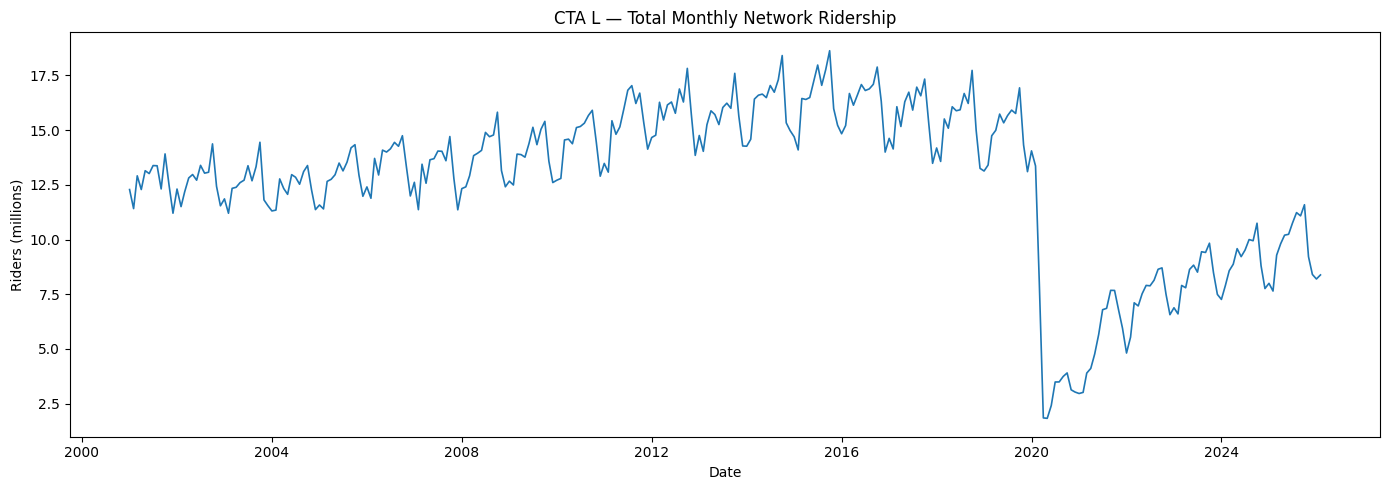

In [46]:
# Monthly network total — good macro view
monthly_net = (
    df3.groupby(['year', 'month'])['total_ridership']
       .sum()
       .reset_index()
)
monthly_net['period'] = pd.to_datetime(
    monthly_net[['year', 'month']].assign(day=1)
)

fig, ax = plt.subplots()
ax.plot(monthly_net['period'], monthly_net['total_ridership'] / 1e6, lw=1.2)
ax.set_title('CTA L — Total Monthly Network Ridership')
ax.set_ylabel('Riders (millions)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

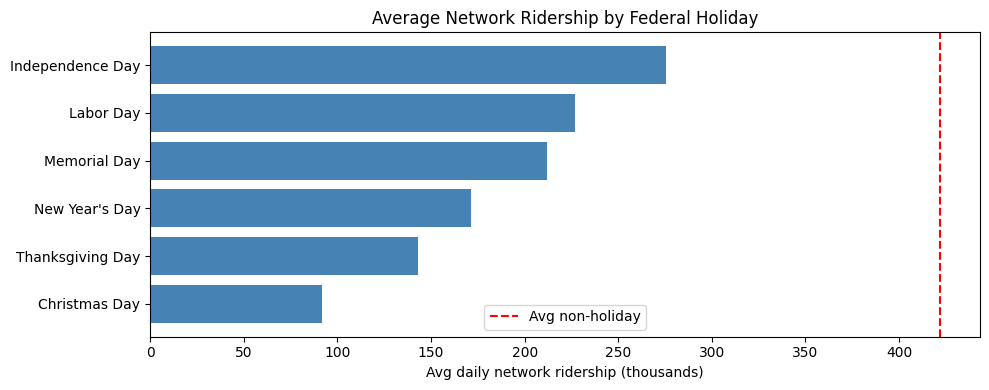

In [47]:
# Holiday ridership comparison
holiday_df = df3[df3['holiday'].notna()].copy()
holiday_avg = (
    holiday_df.groupby('holiday')['total_ridership']
              .mean()
              .sort_values()
)
non_holiday_avg = df3[df3['holiday'].isna()]['total_ridership'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(holiday_avg.index, holiday_avg.values / 1e3, color='steelblue')
ax.axvline(non_holiday_avg / 1e3, color='red', linestyle='--', label='Avg non-holiday')
ax.set_xlabel('Avg daily network ridership (thousands)')
ax.set_title('Average Network Ridership by Federal Holiday')
ax.legend()
plt.tight_layout()
plt.show()

## 6 — Question 2: Saturday vs. Sunday ridership (paired t-test)

In [48]:
# Use df3 (network daily totals) and filter to non-holiday Saturdays & Sundays
# so holiday 'U' days don't contaminate the Sunday sample.
weekends = df3[
    df3['day_of_week'].isin(['Saturday', 'Sunday']) &
    df3['holiday'].isna()
].copy()

# Pair by (year, week): each week contributes one Saturday and one Sunday.
sat = weekends[weekends['day_of_week'] == 'Saturday'][['year', 'week', 'total_ridership']].rename(columns={'total_ridership': 'sat'})
sun = weekends[weekends['day_of_week'] == 'Sunday'][['year', 'week', 'total_ridership']].rename(columns={'total_ridership': 'sun'})

paired = sat.merge(sun, on=['year', 'week'])
print(f"Paired observations: {len(paired):,}")

t_stat, p_value = stats.ttest_rel(paired['sat'], paired['sun'])
diff = paired['sat'] - paired['sun']

print(f"\nSaturday mean: {paired['sat'].mean():,.0f}")
print(f"Sunday mean:   {paired['sun'].mean():,.0f}")
print(f"Mean difference (Sat − Sun): {diff.mean():,.0f}")
print(f"\nPaired t-test: t = {t_stat:.4f},  p = {p_value:.2e}")
if p_value < 0.05:
    print("→ The difference is statistically significant (p < 0.05).")
else:
    print("→ No statistically significant difference detected.")

Paired observations: 1,294

Saturday mean: 295,468
Sunday mean:   218,864
Mean difference (Sat − Sun): 76,604

Paired t-test: t = 74.4094,  p = 0.00e+00
→ The difference is statistically significant (p < 0.05).


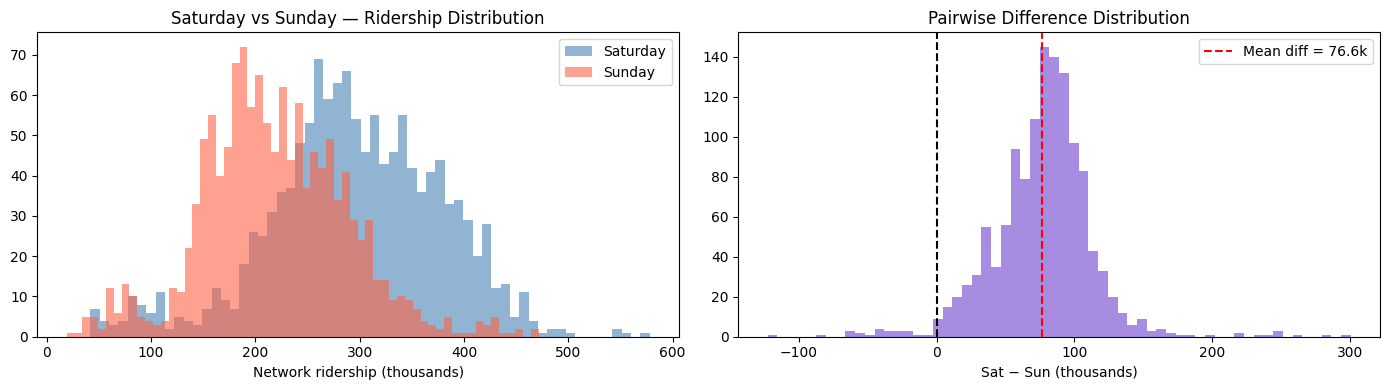

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution comparison
axes[0].hist(paired['sat'] / 1e3, bins=60, alpha=0.6, label='Saturday', color='steelblue')
axes[0].hist(paired['sun'] / 1e3, bins=60, alpha=0.6, label='Sunday',   color='tomato')
axes[0].set_xlabel('Network ridership (thousands)')
axes[0].set_title('Saturday vs Sunday — Ridership Distribution')
axes[0].legend()

# Difference distribution
axes[1].hist(diff / 1e3, bins=60, color='mediumpurple', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].axvline(diff.mean() / 1e3, color='red', linestyle='--', label=f'Mean diff = {diff.mean()/1e3:.1f}k')
axes[1].set_xlabel('Sat − Sun (thousands)')
axes[1].set_title('Pairwise Difference Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7 — Question 1: Predict monthly ridership (linear regression)

We aggregate to the **monthly network level** and use a `LinearRegression` model with these features:

| Feature | Why |
|---|---|
| `year_norm` | Long-run trend (growth pre-COVID, decline after) |
| `month_sin`, `month_cos` | Cyclical seasonality — encodes December and January as *close* |
| `n_weekdays`, `n_saturdays`, `n_sundays` | Calendar composition varies month to month |
| `n_holidays` | Federal holidays depress ridership |
| `is_covid` | Binary flag for Mar 2020 – Dec 2021; the pandemic caused a structural break that a linear trend alone cannot absorb |

20% of months are randomly held out for evaluation.

In [50]:
# Build a monthly network-level dataframe with engineered features.
monthly_model = (
    df3.groupby(['year', 'month'])
       .agg(
           total_ridership=('total_ridership', 'sum'),
           n_weekdays=('day_of_week', lambda s: s.isin(['Monday','Tuesday','Wednesday','Thursday','Friday']).sum()),
           n_saturdays=('day_of_week', lambda s: (s == 'Saturday').sum()),
           n_sundays=('day_of_week', lambda s: (s == 'Sunday').sum()),
           n_holidays=('holiday', lambda s: s.notna().sum()),
       )
       .reset_index()
)

# Encode month as cyclical features so Dec/Jan are treated as close.
monthly_model['month_sin'] = np.sin(2 * np.pi * monthly_model['month'] / 12)
monthly_model['month_cos'] = np.cos(2 * np.pi * monthly_model['month'] / 12)

# Year trend (normalised to start at 0)
monthly_model['year_norm'] = monthly_model['year'] - monthly_model['year'].min()

# COVID-era flag: ridership collapsed in March 2020 and remained structurally
# depressed through 2021. Without this flag the model treats those months as
# ordinary low-ridership periods and the residuals are enormous.
monthly_model['is_covid'] = (
    (monthly_model['year'].astype(int) == 2020) & (monthly_model['month'] >= 3) |
    (monthly_model['year'].astype(int) == 2021)
).astype(int)

FEATURES = ['year_norm', 'month_sin', 'month_cos',
            'n_weekdays', 'n_saturdays', 'n_sundays', 'n_holidays', 'is_covid']
TARGET   = 'total_ridership'

X = monthly_model[FEATURES].values
y = monthly_model[TARGET].values

# Random 20% hold-out
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(X)), test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Test MAE : {mae:,.0f} riders/month")
print(f"Test R²  : {r2:.4f}")
print(f"\nFeature coefficients:")
for name, coef in zip(FEATURES, model.coef_):
    print(f"  {name:20s}  {coef:+,.1f}")

Test MAE : 2,086,061 riders/month
Test R²  : 0.5394

Feature coefficients:
  year_norm             -96,181.5
  month_sin             -890,992.8
  month_cos             -668,527.8
  n_weekdays            +453,529.7
  n_saturdays           +266,778.7
  n_sundays             -28,031.2
  n_holidays            -827,877.7
  is_covid              -8,249,783.3


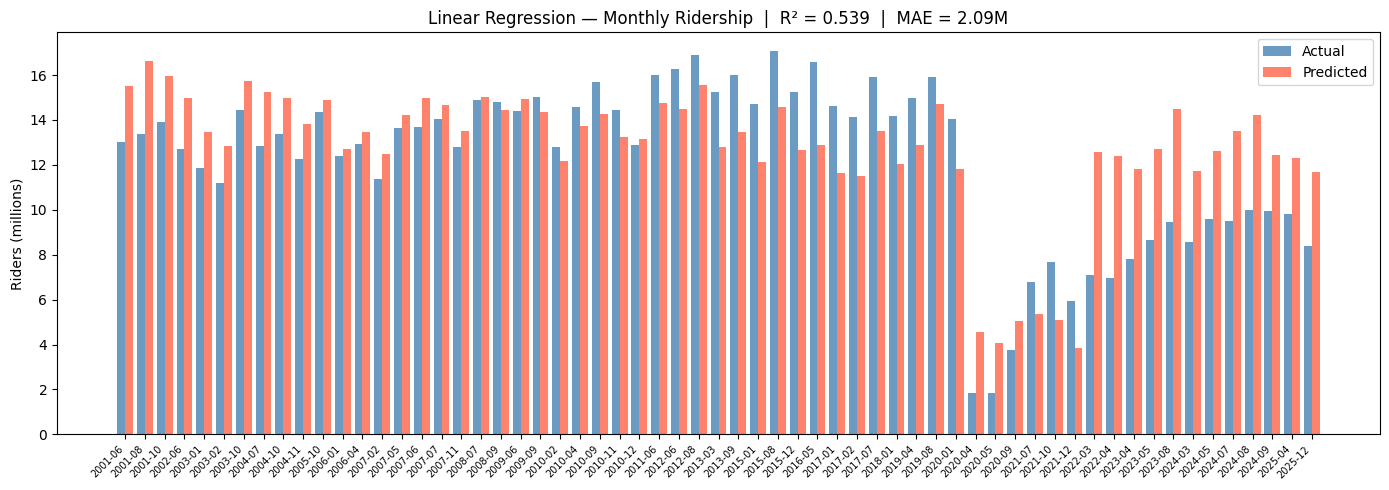

In [51]:
# Visualise predictions vs actuals on the held-out months
test_rows = monthly_model.iloc[idx_test].copy()
test_rows['predicted'] = y_pred
test_rows['actual']    = y_test
test_rows = test_rows.sort_values(['year', 'month'])
test_rows['label'] = test_rows['year'].astype(str) + '-' + test_rows['month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 5))
x_pos = np.arange(len(test_rows))
ax.bar(x_pos - 0.2, test_rows['actual']    / 1e6, width=0.4, label='Actual',    color='steelblue', alpha=0.8)
ax.bar(x_pos + 0.2, test_rows['predicted'] / 1e6, width=0.4, label='Predicted', color='tomato',    alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(test_rows['label'], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Riders (millions)')
ax.set_title(f'Linear Regression — Monthly Ridership  |  R² = {r2:.3f}  |  MAE = {mae/1e6:.2f}M')
ax.legend()
plt.tight_layout()
plt.show()

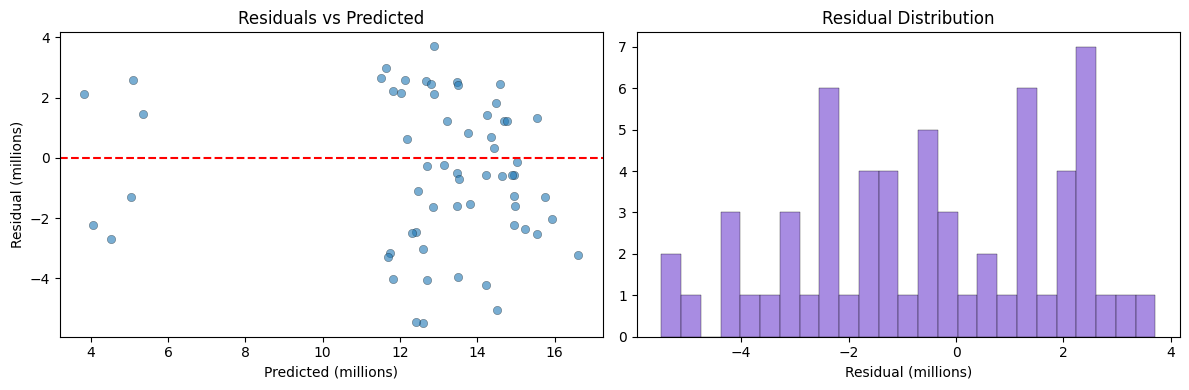

In [52]:
# Residuals
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred / 1e6, residuals / 1e6, alpha=0.6, edgecolors='k', linewidths=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted (millions)')
axes[0].set_ylabel('Residual (millions)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals / 1e6, bins=25, color='mediumpurple', alpha=0.8, edgecolor='k', linewidth=0.3)
axes[1].set_xlabel('Residual (millions)')
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

## 8 — Question 3: Animated ridership heatmap on the CTA map

In [53]:
# Load the Lstops file and extract lat/lon + MAP_ID (= station_id in ridership data)
stops_raw = pd.read_csv(LSTOPS_RAW)
stops_raw.columns = stops_raw.columns.str.strip()

# Location column looks like "    (41.857908, -87.669147)"
loc = stops_raw['Location'].str.extract(r'\(\s*([\d.\-]+),\s*([\d.\-]+)\s*\)')
stops_raw['lat'] = loc[0].astype(float)
stops_raw['lon'] = loc[1].astype(float)

# MAP_ID links to station_id in the ridership data; each MAP_ID has two stop rows
# (two directions), so deduplicate to one row per station.
stations = (
    stops_raw[['MAP_ID', 'STATION_NAME', 'lat', 'lon']]
    .drop_duplicates(subset='MAP_ID')
    .rename(columns={'MAP_ID': 'station_id', 'STATION_NAME': 'stationname'})
)
print(f"{len(stations)} unique stations in Lstops")
stations.head()

144 unique stations in Lstops


,station_id,stationname,lat,lon
0,40830,18th,41.857908,-87.669147
2,40120,35th/Archer,41.829353,-87.680622
4,41120,35th-Bronzeville-IIT,41.831677,-87.625826
6,41270,43rd,41.816462,-87.619021
8,41080,47th,41.809209,-87.618826


In [54]:
# Build monthly station ridership — join with coords
station_monthly = (
    df1.groupby(['station_id', 'year', 'month'])['ridership']
       .sum()
       .reset_index()
)
station_monthly = station_monthly.merge(stations[['station_id', 'lat', 'lon']], on='station_id', how='inner')
station_monthly['period'] = pd.to_datetime(
    station_monthly[['year', 'month']].assign(day=1)
)
print(f"{len(station_monthly):,} station-month rows after join")

42,554 station-month rows after join


In [55]:
import contextily as ctx
from pyproj import Transformer

# Reproject station coords from WGS-84 (lon/lat) → Web Mercator (EPSG:3857),
# which is what contextily tile providers expect.
_proj = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

def to_mercator(lons, lats):
    x, y = _proj.transform(lons.values, lats.values)
    return x, y

station_monthly['x'], station_monthly['y'] = to_mercator(
    station_monthly['lon'], station_monthly['lat']
)
stations['x'], stations['y'] = to_mercator(stations['lon'], stations['lat'])

periods     = sorted(station_monthly['period'].unique())
global_max  = station_monthly['ridership'].max()
global_min  = station_monthly['ridership'].min()
norm = Normalize(vmin=global_min, vmax=global_max)
cmap = plt.cm.YlOrRd

# Axis extent with a small buffer (in metres, since we're in Web Mercator)
PAD = 3000
xlim = (stations['x'].min() - PAD, stations['x'].max() + PAD)
ylim = (stations['y'].min() - PAD, stations['y'].max() + PAD)

fig, ax = plt.subplots(figsize=(9, 11))
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_axis_off()

# Draw the tile basemap once — CartoDB Dark Matter looks great against
# the YlOrRd colour scale.  zoom=13 gives street-level detail for Chicago.
ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatter, zoom=13)

sm   = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.01, shrink=0.6)
cbar.set_label('Monthly ridership', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
fig.patch.set_facecolor('#0d0d0d')

first = station_monthly[station_monthly['period'] == periods[0]]
sc = ax.scatter(
    first['x'], first['y'],
    c=first['ridership'], cmap=cmap, norm=norm,
    s=first['ridership'] / global_max * 300 + 10,
    alpha=0.85, zorder=3, linewidths=0
)
title = ax.text(
    0.5, 0.97, str(periods[0])[:7],
    transform=ax.transAxes, ha='center', va='top',
    color='white', fontsize=15, fontweight='bold'
)

def update(frame):
    p   = periods[frame]
    sub = station_monthly[station_monthly['period'] == p]
    sc.set_offsets(np.column_stack([sub['x'], sub['y']]))
    sc.set_array(sub['ridership'].values)
    sc.set_sizes(sub['ridership'].values / global_max * 300 + 10)
    title.set_text(str(p)[:7])
    return sc, title

ani = animation.FuncAnimation(
    fig, update, frames=len(periods),
    interval=120, blit=True, repeat=True
)

plt.tight_layout(pad=0)
ani.save('ridership_animation.gif', writer='pillow', fps=8, dpi=100)
plt.close()
print("Saved ridership_animation.gif")
display(HTML('<img src="ridership_animation.gif" width="600">'))

Saved ridership_animation.gif


In [56]:
import json

# --- Build data payload ---
stations_info = {
    str(int(sid)): {
        'stationname': str(row['stationname']).strip(),
        'lat': row['lat'],
        'lon': row['lon'],
    }
    for sid, row in stations.set_index('station_id').iterrows()
}

# Pivot to wide: index=period string, columns=station_id string
pivot = station_monthly.pivot_table(
    index='period', columns='station_id', values='ridership', aggfunc='sum'
)
pivot.index = pivot.index.strftime('%Y-%m')
pivot.columns = pivot.columns.astype(int).astype(str)

ridership_by_period = {
    period: {sid: int(v) for sid, v in row.dropna().items()}
    for period, row in pivot.iterrows()
}

data_payload = json.dumps({
    'stations':   stations_info,
    'periods':    sorted(pivot.index.tolist()),
    'ridership':  ridership_by_period,
    'global_max': int(station_monthly['ridership'].max()),
}, separators=(',', ':'))

# --- HTML template (Leaflet + custom controls) ---
HTML = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"/>
<title>CTA L Ridership</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<style>
  *{margin:0;padding:0;box-sizing:border-box}
  body{background:#0d0d0d;color:#fff;font-family:system-ui,sans-serif;display:flex;flex-direction:column;height:100vh;overflow:hidden}
  #map{flex:1}
  #controls{
    background:rgba(13,13,13,0.95);
    padding:12px 20px;
    display:flex;align-items:center;gap:12px;
    border-top:1px solid #2a2a2a;
    user-select:none;
  }
  #period-label{font-size:1.3rem;font-weight:700;min-width:80px;text-align:center;color:#f4a261;letter-spacing:.05em}
  button{background:#2a2a2a;color:#fff;border:none;border-radius:6px;padding:7px 16px;cursor:pointer;font-size:1rem;transition:background .15s}
  button:hover{background:#444}
  #play{min-width:80px}
  #slider{flex:1;accent-color:#f4a261;cursor:pointer;height:4px}
  #legend{
    position:absolute;bottom:75px;right:14px;
    background:rgba(13,13,13,0.88);border-radius:8px;
    padding:10px 14px;z-index:1000;font-size:.72rem;color:#ccc;
  }
  #legend-bar{
    width:130px;height:10px;border-radius:3px;margin-bottom:5px;
    background:linear-gradient(to right,#ffffb2,#fecc5c,#fd8d3c,#f03b20,#bd0026);
  }
  #legend-labels{display:flex;justify-content:space-between}
  .leaflet-tooltip{background:#111;border:1px solid #444;color:#eee;font-size:.8rem}
</style>
</head>
<body>
<div id="map"></div>
<div id="controls">
  <button id="prev" title="Previous month (←)">&#8592;</button>
  <button id="play">&#9654; Play</button>
  <input type="range" id="slider" min="0" step="1"/>
  <button id="next" title="Next month (→)">&#8594;</button>
  <span id="period-label"></span>
</div>
<div id="legend">
  <div id="legend-bar"></div>
  <div id="legend-labels"><span>Low</span><span>High</span></div>
  <div style="margin-top:5px">Monthly boardings</div>
</div>
<script>
const DATA = DATA_PLACEHOLDER;

const map = L.map('map',{zoomControl:true}).setView([41.875,-87.64],11);
L.tileLayer('https://{s}.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}{r}.png',{
  attribution:'&copy; OpenStreetMap &copy; CARTO',maxZoom:19
}).addTo(map);

// YlOrRd colour ramp (matches matplotlib)
const STOPS=[[0,[255,255,178]],[.25,[254,204,92]],[.5,[253,141,60]],[.75,[240,59,32]],[1,[189,0,38]]];
function lerp(a,b,t){return a+(b-a)*t}
function toColor(val){
  const t=Math.min(val/DATA.global_max,1);
  for(let i=1;i<STOPS.length;i++){
    const[t0,c0]=STOPS[i-1],[t1,c1]=STOPS[i];
    if(t<=t1){
      const f=(t-t0)/(t1-t0);
      return`rgb(${Math.round(lerp(c0[0],c1[0],f))},${Math.round(lerp(c0[1],c1[1],f))},${Math.round(lerp(c0[2],c1[2],f))})`;
    }
  }
  return'rgb(189,0,38)';
}
function toRadius(val){return 3+(val/DATA.global_max)*24}

// Create one persistent CircleMarker per station
const circles={};
for(const[sid,info] of Object.entries(DATA.stations)){
  circles[sid]=L.circleMarker([info.lat,info.lon],{
    radius:3,weight:0,fillOpacity:.85,fillColor:'#ffffb2'
  }).addTo(map).bindTooltip('',{sticky:true});
}

const periods=DATA.periods;
const slider=document.getElementById('slider');
const label=document.getElementById('period-label');
const playBtn=document.getElementById('play');
slider.max=periods.length-1;

function render(idx){
  idx=Math.max(0,Math.min(periods.length-1,idx));
  const period=periods[idx];
  const monthly=DATA.ridership[period]||{};
  label.textContent=period;
  slider.value=idx;
  for(const[sid,circle] of Object.entries(circles)){
    const val=monthly[sid]||0;
    const col=toColor(val);
    circle.setStyle({fillColor:col,color:col});
    circle.setRadius(toRadius(val));
    circle.setTooltipContent(
      `<b>${DATA.stations[sid].stationname}</b><br/>`+
      `${val.toLocaleString()} boardings<br/>${period}`
    );
  }
}

render(0);

slider.addEventListener('input',()=>render(parseInt(slider.value)));
document.getElementById('prev').addEventListener('click',()=>render(parseInt(slider.value)-1));
document.getElementById('next').addEventListener('click',()=>render(parseInt(slider.value)+1));

// Keyboard navigation
document.addEventListener('keydown',e=>{
  if(e.key==='ArrowLeft') render(parseInt(slider.value)-1);
  if(e.key==='ArrowRight') render(parseInt(slider.value)+1);
});

let timer=null;
playBtn.addEventListener('click',()=>{
  if(timer){clearInterval(timer);timer=null;playBtn.innerHTML='&#9654; Play';}
  else{
    playBtn.innerHTML='&#9646;&#9646; Pause';
    timer=setInterval(()=>{
      let i=parseInt(slider.value)+1;
      if(i>=periods.length)i=0;
      render(i);
    },150);
  }
});
</script>
</body>
</html>"""

html_out = HTML.replace('DATA_PLACEHOLDER', data_payload)
with open('ridership_map.html', 'w') as f:
    f.write(html_out)
print(f"Saved ridership_map.html  ({len(html_out)/1024:.0f} KB)")

Saved ridership_map.html  (613 KB)


## 9 — Appendix: year-over-year ridership per station (top 10)

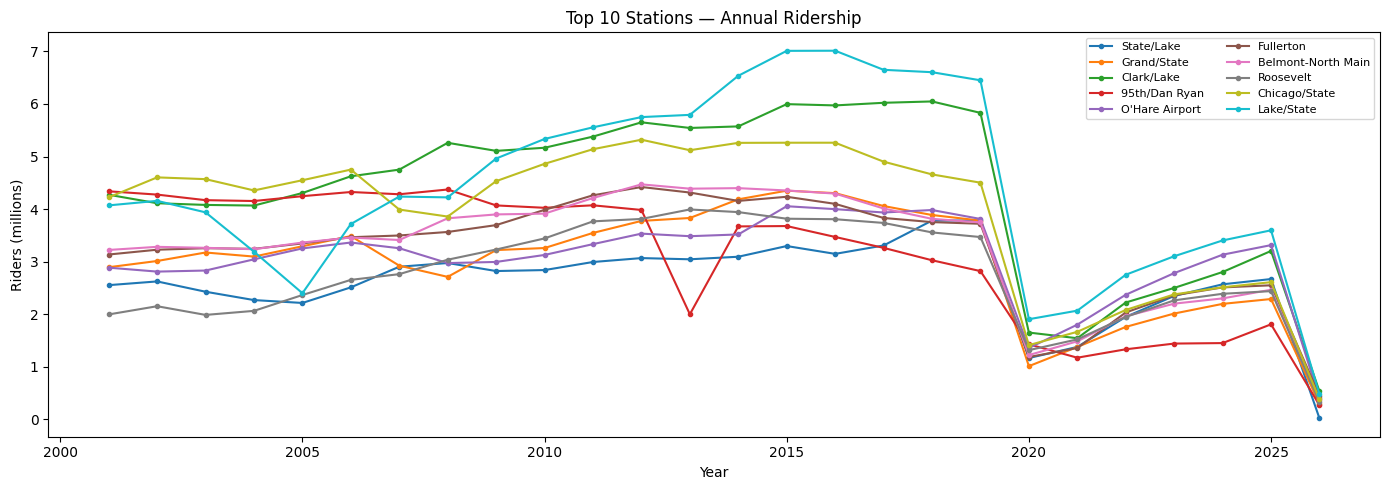

In [57]:
top10 = (
    df2.groupby('station_id')['yearly_ridership']
       .mean()
       .nlargest(10)
       .index.tolist()
)
top10_names = df2[df2['station_id'].isin(top10)][['station_id','stationname']].drop_duplicates().set_index('station_id')['stationname']

yearly_top = (
    df2[df2['station_id'].isin(top10)]
    .groupby(['station_id', 'year'])['yearly_ridership']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for sid, grp in yearly_top.groupby('station_id'):
    ax.plot(grp['year'], grp['yearly_ridership'] / 1e6, label=top10_names[sid], marker='o', markersize=3)
ax.set_title('Top 10 Stations — Annual Ridership')
ax.set_ylabel('Riders (millions)')
ax.set_xlabel('Year')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()